## Getting data

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# dataset with number 28x28 pixels
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [8]:
X, y = mnist.data, mnist.target

In [9]:
X.shape

(70000, 784)

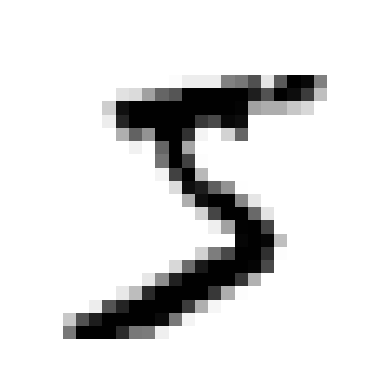

In [10]:
def plot_num(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis('off')
    
num = X[0]

plot_num(num)

In [11]:
y[13]

'6'

In [12]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [13]:
# predicting 5
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")
y_train_5

array([ True, False, False, ...,  True, False, False], shape=(60000,))

In [14]:
from sklearn.linear_model import SGDClassifier

classifier = SGDClassifier(random_state=52)

classifier.fit(X_train, y_train_5)

classifier.predict([num])

array([ True])

In [15]:
#evaluating

from sklearn.model_selection import cross_val_score

cross_val_score(classifier, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.961  , 0.9569 , 0.96185])

In [16]:
#put values to the most frequent set
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
dummy.fit(X_train, y_train_5)
print(any(dummy.predict(X_train))) #prints True if there is at least one '5'
print(cross_val_score(dummy, X_train, y_train_5, cv=3, scoring="accuracy"))

False
[0.90965 0.90965 0.90965]


In [17]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

strat = StratifiedKFold(n_splits=3)

for train_index, test_index in strat.split(X_train, y_train_5):
    classifier_clone = clone(classifier)
    
    
    X_train_cv = X_train[train_index]
    y_train_cv = y_train_5[train_index]
    
    X_test_cv = X_train[test_index]
    y_test_cv = y_train_5[test_index]
    
    
    classifier_clone.fit(X_train_cv, y_train_cv)
    predictions = classifier_clone.predict(X_test_cv)
    hits = sum(predictions == y_test_cv)
    print((hits/len(y_test_cv)))

0.961
0.9569
0.96185


In [18]:
from sklearn.model_selection import cross_val_predict

y_predictions_5 = cross_val_predict(classifier, X_train, y_train_5, cv=3)

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_predictions_5)
cm

array([[53506,  1073],
       [ 1332,  4089]])

In [20]:
# precisions and recall
from sklearn.metrics import precision_score, recall_score, f1_score

pr = precision_score(y_train_5, y_predictions_5)
rc = recall_score(y_train_5, y_predictions_5)
f1 = f1_score(y_train_5, y_predictions_5)
print("pr", pr)
print('rc', rc)
print("f1", f1)

pr 0.7921348314606742
rc 0.7542888765910348
f1 0.7727487479920627


In [21]:
# finding out the most optimal treshold
score = classifier.decision_function([num])
treshold = 0 #default
print(score, (score > treshold))

[807.04578696] [ True]


In [22]:
y_scores_5 = cross_val_predict(classifier, X_train, y_train_5, cv=3, method='decision_function')

In [23]:
from sklearn.metrics import precision_recall_curve

precision, recall, treshold = precision_recall_curve(y_train_5, y_scores_5)

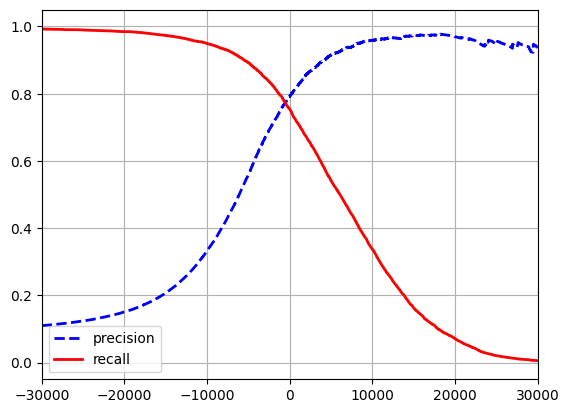

In [24]:
plt.plot(treshold, precision[:-1], "b--", linewidth=2, label="precision")
plt.plot(treshold, recall[:-1], "r", linewidth=2, label="recall")

plt.xlim(-30000, 30000)
plt.legend()
plt.grid(True)
plt.show()

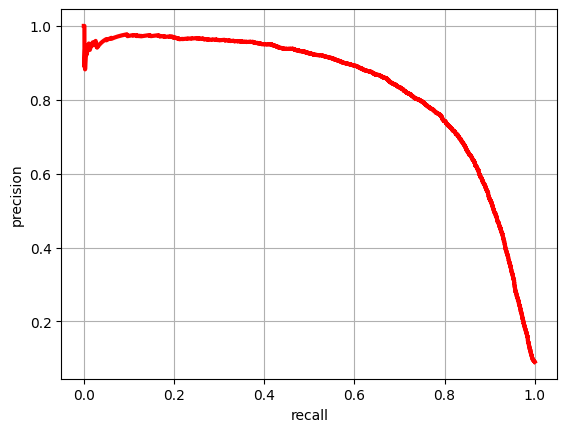

In [25]:
plt.plot(recall, precision, "r", linewidth=3)

plt.xlabel('recall')
plt.ylabel('precision')
plt.grid(True)
plt.show()

In [26]:
#getting min value for precision 90%
treshold_90_it = (precision >= 0.90).argmax()
treshold_90 = treshold[treshold_90_it]
treshold_90

np.float64(4215.277827396328)

In [27]:
#wb recall?
y_predicted = (y_scores_5 >= treshold_90)
print('rc',recall_score(y_train_5, y_predicted))
print('pr',precision_score(y_train_5, y_predicted))

rc 0.5768308430178933
pr 0.9001151410477836


In [28]:

a = np.array([8, 7, 6, 5, 4, 3, 2, 1])
(a <= 3)

array([False, False, False, False, False,  True,  True,  True])

In [29]:
#ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, treshold = roc_curve(y_train_5, y_scores_5)

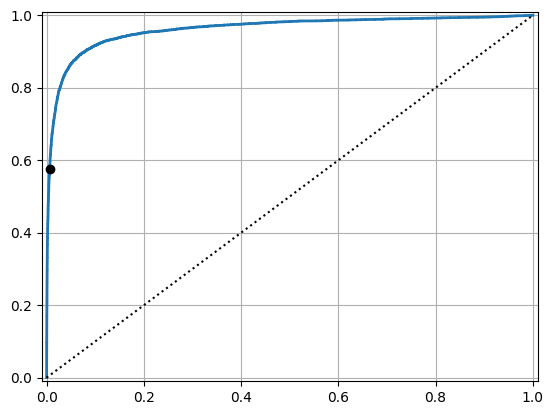

In [30]:
treshold_90_it = (treshold <= treshold_90).argmax()
fpr_90, tpr_90 = fpr[treshold_90_it], tpr[treshold_90_it]

plt.plot(fpr, tpr, linewidth=2)
plt.plot(fpr_90, tpr_90, 'ko')
plt.plot([0,1], [0,1], 'k:')

plt.xlim(-0.01,1.01)
plt.ylim(-0.01,1.01)

plt.grid(True)
plt.show()

In [31]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores_5)

0.9617244992804492

In [32]:
# trying out another model
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=52)

forest_scores = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba')
forest_scores[:2]

array([[0.2, 0.8],
       [1. , 0. ]])

In [33]:
y_forest_pred = forest_scores[:,1]

forest_pr, forest_rc, forest_th = precision_recall_curve(y_train_5, y_forest_pred)

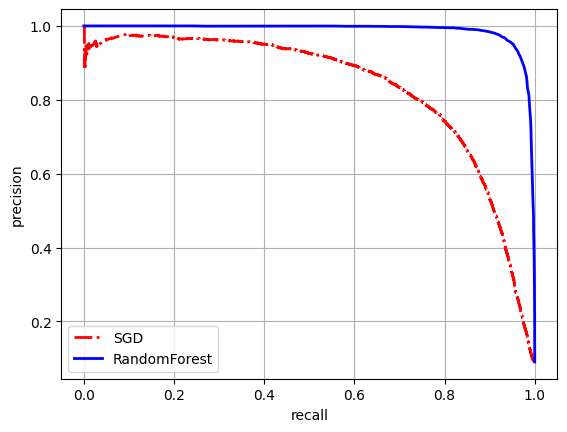

In [34]:
plt.plot(recall, precision, "r-.", linewidth=2, label="SGD")
plt.plot(forest_rc, forest_pr, "b", linewidth=2, label="RandomForest")

plt.xlabel('recall')
plt.ylabel('precision')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
y_rf_pred = (y_forest_pred >= 0.5) 

print(f1_score(y_train_5, y_rf_pred))
print(roc_auc_score(y_train_5, y_forest_pred))


0.927135431989801
0.9982289802489048


In [36]:
fcm = confusion_matrix(y_train_5, y_rf_pred)
fcm

array([[54530,    49],
       [  694,  4727]])

## Multiclass

In [37]:
from sklearn.svm import SVC #OVO

svc_cls = SVC(random_state=52)
svc_cls.fit(X_train[:2000], y_train[:2000])

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [38]:
svc_cls.predict([num])

array(['5'], dtype=object)

In [39]:
svc_score = svc_cls.decision_function([num]).round(3)
print(svc_score)
class_id = svc_score.argmax()
print(svc_cls.classes_)
svc_cls.classes_[class_id]

[[ 3.793  0.729  6.062  8.298 -0.294  9.302  1.747  2.774  7.206  4.822]]
['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


'5'

In [40]:
from sklearn.multiclass import OneVsRestClassifier #OVR

ovr_cls = OneVsRestClassifier(SVC(random_state=52))
ovr_cls.fit(X_train[:2000], y_train[:2000])
ovr_cls.predict([num])

array(['5'], dtype='<U1')

In [41]:
len(ovr_cls.estimators_)

10

In [42]:
sgd_cls = SGDClassifier(random_state=52)
sgd_cls.fit(X_train[:2000], y_train[:2000])
sgd_cls.predict([num])

array(['5'], dtype='<U1')

In [43]:
sgd_cls.decision_function([num]).round() # '5' = 52100

array([[-2107597., -1612674., -1938805.,  -134816., -3162774.,    52100.,
        -2597735., -2856921., -1414322., -2097303.]])

In [44]:
# 2m 38s
cross_val_score(sgd_cls, X_train, y_train, cv=3, scoring='accuracy')

array([0.8627 , 0.88015, 0.85875])

In [45]:
# better with standartization but slower 6m 43s
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype('float64'))



In [46]:
cross_val_score(sgd_cls, X_train_scaled, y_train, cv=3, scoring='accuracy')

/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.901  , 0.89895, 0.89885])

## Error Analysis

In [47]:
y_pred = cross_val_predict(sgd_cls, X_train_scaled, y_train, cv=3)

/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


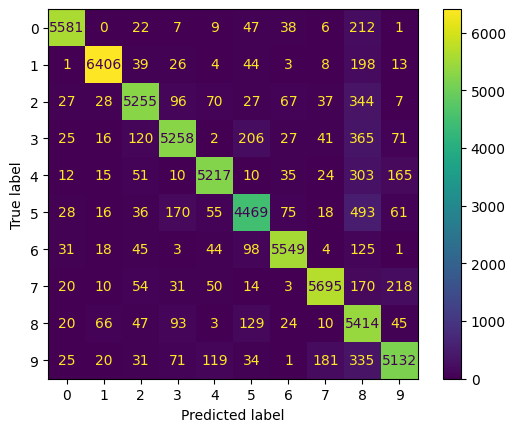

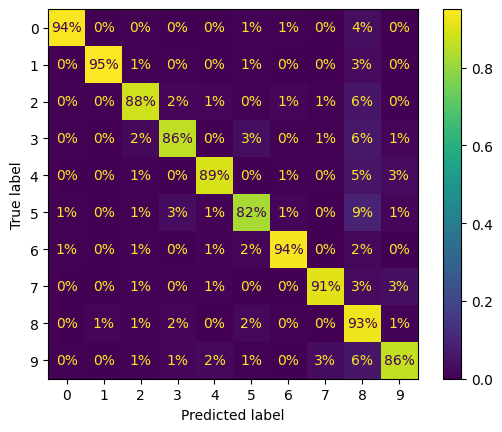

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

#simple Confusion matrux
ConfusionMatrixDisplay.from_predictions(y_train, y_pred)
#Error rate cm
ConfusionMatrixDisplay.from_predictions(y_train, y_pred, normalize='true', values_format='.0%')
plt.show()

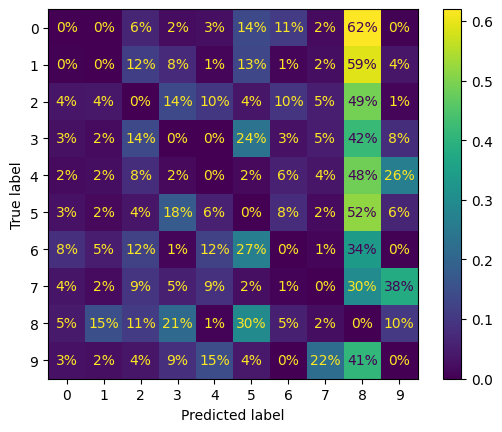

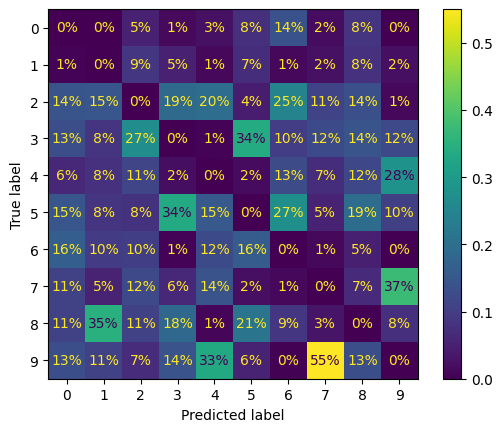

In [49]:
sample_weight = (y_train != y_pred)
#Error rate (error_of_value/total_errors) reagrding to true values
ConfusionMatrixDisplay.from_predictions(y_train, y_pred, sample_weight=sample_weight, normalize='true', values_format='.0%')
#Same shit, but regarding to predicted values
ConfusionMatrixDisplay.from_predictions(y_train, y_pred, sample_weight=sample_weight, normalize='pred', values_format='.0%')
plt.show()

Text(0.42, 0.95, 'predicted')

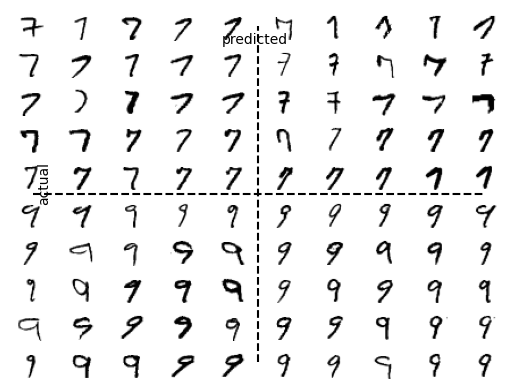

In [50]:
cl_a, cl_b = '7', '9'

X_train_aa = X_train[(y_train == cl_a) & (y_pred == cl_a)]
X_train_ab = X_train[(y_train == cl_a) & (y_pred == cl_b)]
X_train_ba = X_train[(y_train == cl_b) & (y_pred == cl_a)]
X_train_bb = X_train[(y_train == cl_b) & (y_pred == cl_b)]

#fig, ax =plt.subplots(2,2, sharex=False, sharey=False)
x=0
for k in range(1, 6):

    for i in range(1, 6):
        plt.subplot(10,10, i+x)
        plt.axis('off')
        plt.imshow(X_train_aa[i+k*5-5].reshape(28, 28), cmap='binary')

    x+=5
    for i in range(1, 6):
        plt.subplot(10,10, i+x)
        plt.axis('off')
        plt.imshow(X_train_ab[i+k*5-5].reshape(28, 28), cmap='binary')
    x+=5
    
    
    
x=0
for k in range(1, 6):

    for i in range(1, 6):
        plt.subplot(10,10, i+x+50)
        plt.axis('off')
        plt.imshow(X_train_ba[i+k*5-5].reshape(28, 28), cmap='binary')

    x+=5
    for i in range(1, 6):
        plt.subplot(10,10, i+x+50)
        plt.axis('off')
        plt.imshow(X_train_bb[i+k*5-5].reshape(28, 28), cmap='binary')
    x+=5
    
    
plt.subplot(1,1,1)
plt.axis('off')
plt.plot([0.5,0.5],[0,1], 'k--')
plt.axis('off')
plt.plot([0,1],[0.5,0.5], 'k--')
# for i in range(1, 26):
#   plt.subplot(5,5, i)
#   plt.axis('off')
#   plt.imshow(X_train_aa[i].reshape(28, 28), cmap='binary')

plt.text(0.01, 0.48,"actual", rotation=90)
plt.text(0.42, 0.95,"predicted")

## Multilabel classification

In [51]:
from sklearn.neighbors import KNeighborsClassifier

y_large = (y_train >= '7')
y_odd = (y_train.astype('int8') % 2 == 1)
y_multiclass = np.c_[y_large, y_odd] 

kn_cls = KNeighborsClassifier()
kn_cls.fit(X_train, y_multiclass)
kn_cls.predict([num])

array([[False,  True]])

In [52]:
y_knn_cv = cross_val_predict(kn_cls, X_train, y_multiclass, cv=3)
f1_score(y_multiclass, y_knn_cv, average='macro')

0.9764102655606048

In [53]:
from sklearn.multioutput import ClassifierChain

chain_cls = ClassifierChain(SVC(), cv=3, random_state=52)
chain_cls.fit(X_train[:2000], y_multiclass[:2000])
chain_cls.predict([num])

array([[0., 1.]])

## Multioutput label

In [54]:
rng = np.random.default_rng(seed=52)
noise_train = rng.integers(0, 100, (len(X_train), 784))
X_train_noise = X_train.copy() + noise_train

y_clean = X_train

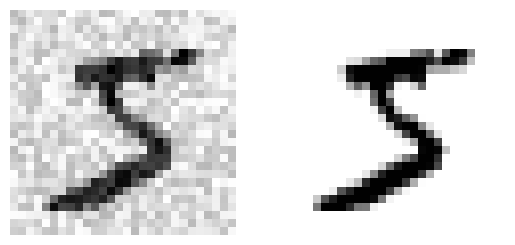

In [55]:
plt.subplot(121)
plot_num(X_train_noise[0])
plt.subplot(122)
plot_num(X_train[0])

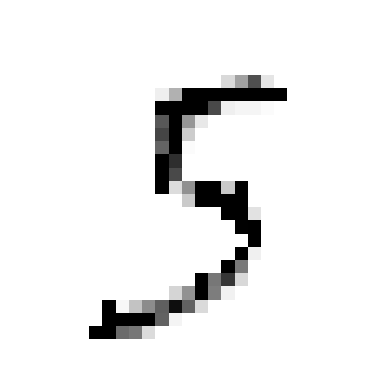

In [56]:
knn_cls = KNeighborsClassifier()
knn_cls.fit(X_train_noise, y_clean)

digit = knn_cls.predict([X_train_noise[0]])
plot_num(digit)

# Execrices

In [57]:
#1 I have to reach 97% accuracy

kn_cls = KNeighborsClassifier()

#kn_cls.fit(X_train, y_train)

cv_kn = cross_val_predict(kn_cls, X_train, y_train, cv=3)

f1_score(y_train, cv_kn, average='macro')

0.9672164755274893

In [58]:
cross_val_score(kn_cls, X_train, y_train, scoring='accuracy', cv=3)

array([0.9676 , 0.9671 , 0.96755])

In [59]:
from sklearn.model_selection import GridSearchCV

params = [{"n_neighbors" : [2, 3, 5, 7], "weights" : ['uniform', 'distance']}]

grid_res = GridSearchCV(kn_cls, params, scoring='accuracy', cv=3)
grid_res.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': [2, 3, ...], 'weights': ['uniform', 'distance']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [60]:
pd.DataFrame(grid_res.cv_results_).sort_values(by='mean_test_score', ascending=False).head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
3,0.082471,0.000169,11.590662,0.033629,3,distance,"{'n_neighbors': 3, 'weights': 'distance'}",0.97040,0.96890,0.96870,0.969333,0.000759,1
5,0.082019,0.000124,11.566248,0.111234,5,distance,"{'n_neighbors': 5, 'weights': 'distance'}",0.96880,0.96795,0.96905,0.968600,0.000471,2
2,0.082018,0.001299,11.570959,0.142754,3,uniform,"{'n_neighbors': 3, 'weights': 'uniform'}",0.96900,0.96805,0.96750,0.968183,0.000620,3
1,0.082314,0.001504,11.511297,0.071454,2,distance,"{'n_neighbors': 2, 'weights': 'distance'}",0.96875,0.96685,0.96705,0.967550,0.000852,4
4,0.082113,0.000975,11.552854,0.128048,5,uniform,"{'n_neighbors': 5, 'weights': 'uniform'}",0.96760,0.96710,0.96755,0.967417,0.000225,5


In [61]:
final_model = grid_res.best_estimator_

cross_val_score(final_model, X_train, y_train, scoring='accuracy', cv=4)

array([0.97153333, 0.97053333, 0.97013333, 0.96966667])

In [62]:
cross_val_score(final_model, X_train_scaled, y_train, scoring='accuracy', cv=4)

array([0.93993333, 0.9462    , 0.94026667, 0.94506667])

## Exercise 2

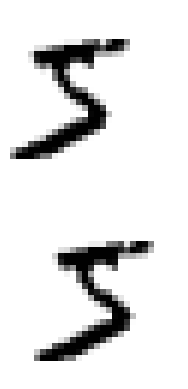

In [63]:
biased = np.delete(X_train[0].copy(), [0, 1, 2, 3])
tt = np.append(biased, [0,0,0,0])

plt.subplot(211)
plot_num(tt)
plt.subplot(212)
plot_num(X_train[0])

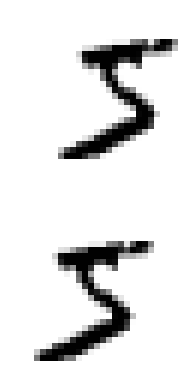

In [64]:
biased = np.insert(X_train[0].copy(), [0,0,0,0], 0)
tt = np.delete(biased, [783, 782, 781, 780])

plt.subplot(211)
plot_num(tt)
plt.subplot(212)
plot_num(X_train[0])

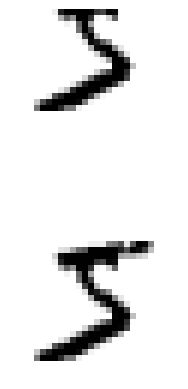

In [65]:
#up
extra = np.zeros(28*8)
arr = np.array(list(range(0,28*8)))

biased = np.delete(X_train[0].copy(), arr)
tt = np.append(biased, extra)

plt.subplot(211)
plot_num(tt)
plt.subplot(212)
plot_num(X_train[0])


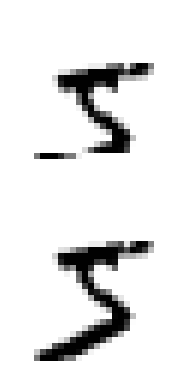

In [66]:
#down
extra = np.zeros(28*4)
arr = 784 - np.array(list( range(0,28*4)))

biased = np.insert(X_train[0].copy(), 0,  extra)
tt = np.delete(biased, arr)

plt.subplot(211)
plot_num(tt)
plt.subplot(212)
plot_num(X_train[0])

In [67]:
def one_pixel_shift(image, direction):
    if(direction==0 or direction=='right'):
        img_extra = np.insert(image.copy(), 0, 0)
        img_shifted = np.delete(img_extra, 783)
        return img_shifted
    
    if(direction==1 or direction=='left'):
        img_extra = np.delete(image.copy(), 0)
        img_shifted = np.append(img_extra, 0)
        return img_shifted
    
    if(direction==2 or direction=='up'):
        one_layer_plus = np.zeros(28)
        one_layer_minus = np.array(list(range(0,28)))

        img_extra = np.delete(X_train[0].copy(), one_layer_minus)
        img_shifted = np.append(img_extra, one_layer_plus)
        return img_shifted

    if(direction==3 or direction=='down'):
        one_layer_plus = np.zeros(28)
        one_layer_minus = 784 - np.array(list( range(0,28)))

        img_extra = np.insert(X_train[0].copy(), 0,  one_layer_plus)
        img_shifted = np.delete(img_extra, one_layer_minus)
        return img_shifted

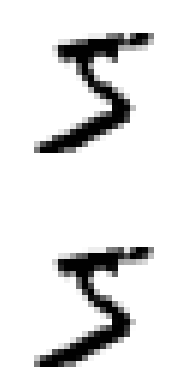

In [68]:
plt.subplot(211)
plot_num(one_pixel_shift(X_train[0], 'up'))
plt.subplot(212)
plot_num(one_pixel_shift(X_train[0], 'down'))

In [69]:
X_train_expanded = []
y_train_expanded = []

for i in range(0, len(X_train)):
    X_train_expanded.append(X_train[i])
    y_train_expanded.append(y_train[i])
    for j in range(0, 4):
        X_train_expanded.append(one_pixel_shift(X_train[i], j))
        y_train_expanded.append(y_train[i])
            
    
X_train_expanded = np.array(X_train_expanded)
y_train_expanded = np.array(y_train_expanded)

In [70]:
len(X_train_expanded)

300000

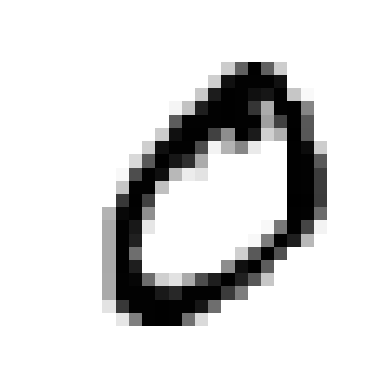

In [71]:
plot_num(X_train_expanded[6])

In [72]:
mnist_expanded = {'data' : X_train_expanded.copy(), 'target' : y_train_expanded.copy()} 

In [76]:
from sklearn.model_selection import train_test_split

X_expanded_train, y_expanded_train, x, y = train_test_split(X_train_expanded, y_train_expanded, test_size=0.2, random_state=52)

In [ ]:
X_expanded_train = np.append(X_expanded_train, y_expanded_train).reshape(300000, 784)

In [86]:
X_expanded_train

array([0., 0., 0., ..., 0., 0., 0.], shape=(235200000,))